In [9]:
import sys

import numpy as np
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"
MODELS_DIR = SOLUTION_DIR / "models"
DENSE_DIR = MODELS_DIR / "dense"

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que se
# importan desde su carpeta. iSpec tampoco se instala como dependencia, pero de
# montarlo se encarga 'iSpec_functions', que lo añade a 'sys.path' al importarse.
sys.path.insert(0, str(MODELS_DIR))

# Ficheros que deja el entrenamiento, cuatro por modelo: el modelo entrenado en
# esta misma carpeta, por ser la salida del cuaderno, y a su lado 'training' con
# el registro de cómo se entrenó y 'test_data' con el conjunto de test que
# consumen las celdas de análisis. Cada modelo lleva su propio `.npz` porque
# cada uno usa una normalización distinta. Esta celda no carga datos, de modo
# que la recarga de una sesión anterior solo necesita ejecutar esta celda y la
# de recarga del modelo que interese.
TRAINING_DIR = DENSE_DIR / "training"
TEST_DATA_DIR = DENSE_DIR / "test_data"

TRAINING_DIR.mkdir(parents=True, exist_ok=True)
TEST_DATA_DIR.mkdir(parents=True, exist_ok=True)

GLOBAL_MODEL_PATH = DENSE_DIR / "dense-global.keras"
GLOBAL_HISTORY_PATH = TRAINING_DIR / "dense-global_training_history.csv"
GLOBAL_SUMMARY_PATH = TRAINING_DIR / "dense-global_training_summary.json"
GLOBAL_TEST_DATA_PATH = TEST_DATA_DIR / "dense-global_test_data.npz"

MEDIAN_MODEL_PATH = DENSE_DIR / "dense-median.keras"
MEDIAN_HISTORY_PATH = TRAINING_DIR / "dense-median_training_history.csv"
MEDIAN_SUMMARY_PATH = TRAINING_DIR / "dense-median_training_summary.json"
MEDIAN_TEST_DATA_PATH = TEST_DATA_DIR / "dense-median_test_data.npz"

MAX_MODEL_PATH = DENSE_DIR / "dense-max.keras"
MAX_HISTORY_PATH = TRAINING_DIR / "dense-max_training_history.csv"
MAX_SUMMARY_PATH = TRAINING_DIR / "dense-max_training_summary.json"
MAX_TEST_DATA_PATH = TEST_DATA_DIR / "dense-max_test_data.npz"

# Predicciones sobre el conjunto de test. No son un checkpoint del
# entrenamiento, sino el dato que consume la comparativa entre arquitecturas,
# así que van en 'data/predictions' y no en la carpeta del cuaderno.
PREDICTIONS_DIR = DATA_DIR / "predictions"

GLOBAL_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-global_predictions.npz"
MEDIAN_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-median_predictions.npz"
MAX_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-max_predictions.npz"

# Tabla del análisis con iSpec de la muestra de espectros de test, con una fila
# por espectro y los parámetros estelares del real y del predicho. Acompaña a
# las predicciones porque, como ellas, se calcula una vez y la leen después la
# comparativa entre arquitecturas y las figuras de error de la memoria.
GLOBAL_ISPEC_PATH = PREDICTIONS_DIR / "ispec_dense-global.csv"
MEDIAN_ISPEC_PATH = PREDICTIONS_DIR / "ispec_dense-median.csv"
MAX_ISPEC_PATH = PREDICTIONS_DIR / "ispec_dense-max.csv"

# Tamaño de lote del entrenamiento, guardado también en cada resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [15]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [16]:
from services.normalization import standardize_splits

# Normalizamos con la media y la desviación típica del conjunto de
# entrenamiento, las mismas para todos los espectros
(X_train_norm_global, X_val_norm_global,
 X_test_norm_global, X_mean, X_std) = standardize_splits(X_train, X_val, X_test)

(y_train_norm_global, y_val_norm_global,
 y_test_norm_global, y_mean, y_std) = standardize_splits(y_train, y_val, y_test)

In [17]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    GLOBAL_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global_test_data.npz')

In [18]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos la estructura del modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

El entrenamiento de cada modelo deja en `models/dense` cuatro ficheros, uno por cada forma de dato: el modelo, que es la salida del cuaderno, en la propia carpeta, y los otros tres repartidos entre `training` y `test_data`, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `<modelo>.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `training/<modelo>_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre normalizaciones. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `training/<modelo>_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `test_data/<modelo>_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores (`X_test`, `y_test`, los identificadores, las longitudes de onda y los estadísticos de la normalización). Son **arrays** de cientos de megabytes, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

Cada modelo lleva su propio `.npz` porque cada uno normaliza el conjunto de test de una forma distinta. La lógica de guardado y recarga vive en `models/services/checkpoints.py`, compartida por todos los cuadernos de entrenamiento. De la normalización se ocupa `models/services/normalization.py`, que reúne los esquemas de todos los cuadernos. La normalización del conjunto de test no se guarda: se rehace a partir de sus estadísticos. De las predicciones se ocupa `models/services/predictions.py`, que las guarda aparte, en `data/predictions/<modelo>_predictions.npz`: no son un checkpoint del entrenamiento sino el dato que consume la comparativa entre arquitecturas.

In [20]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_global = ModelCheckpoint(
    GLOBAL_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_global = CSVLogger(GLOBAL_HISTORY_PATH)

history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_global,
        early_stop,
        reduce_lr,
        save_training_history_global
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model.save(GLOBAL_MODEL_PATH)

model_data_norm_global = history_norm_global.history
save_training_summary(
    GLOBAL_SUMMARY_PATH,
    model_data_norm_global,
    model_path=GLOBAL_MODEL_PATH,
    history_path=GLOBAL_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0279 - mae: 0.1302 - mse: 0.0641
Epoch 1: val_loss improved from None to 0.01354, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - loss: 0.0279 - mae: 0.1302 - mse: 0.0641 - val_loss: 0.0135 - val_mae: 0.0917 - val_mse: 0.0293 - learning_rate: 1.0000e-04
Epoch 2/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0128 - mae: 0.0923 - mse: 0.0276
Epoch 2: val_loss did not improve from 0.01354
511/511 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - loss: 0.0128 - mae: 0.0923 - mse: 0.0276 - val_loss: 0.0137 - val_mae: 0.1034 - val_mse: 0.0295 - learning_rate: 1.0000e-04
Epoch 3/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0117 - mae: 0.0894 - mse: 0.0254
Epoch 3: val_loss improved from 0.013

{'model': 'dense-global.keras',
 'history': 'dense-global_training_history.csv',
 'updated': '2026-09-03T16:21:33',
 'batch_size': 64,
 'epochs_completed': 22,
 'best_epoch': 21,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización global. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [21]:
from services.checkpoints import load_checkpoint, load_test_data
from services.normalization import normalize_standard

model, model_data_norm_global, summary_global = load_checkpoint(
    GLOBAL_MODEL_PATH, GLOBAL_HISTORY_PATH, GLOBAL_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(GLOBAL_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_mean = test_data["X_mean"]
X_std = test_data["X_std"]
y_mean = test_data["y_mean"]
y_std = test_data["y_std"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_global = normalize_standard(X_test, X_mean, X_std)
y_test_norm_global = normalize_standard(y_test, y_mean, y_std)

print("Checkpoint de", summary_global["updated"])
print(
    "Épocas completadas:", summary_global["epochs_completed"],
    "| mejor época:", summary_global["best_epoch"]
)
print("Métricas de test:", summary_global["test_metrics"])

Checkpoint de 2026-09-03T16:21:33
Épocas completadas: 22 | mejor época: 21
Métricas de test: None


Graficamos la evolución de las variables estudiadas en el modelo.

In [22]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

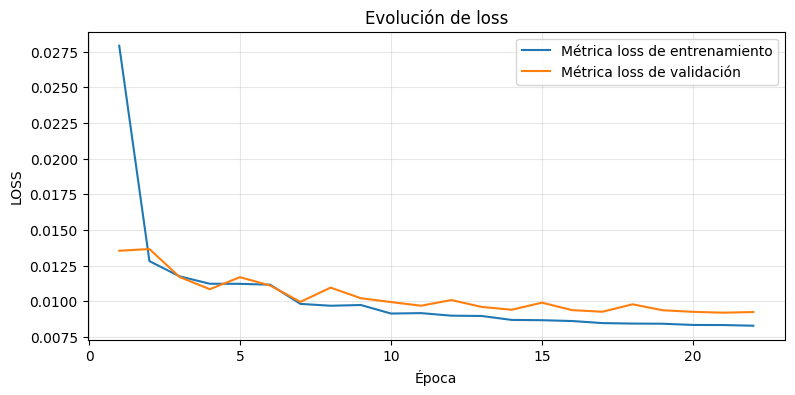

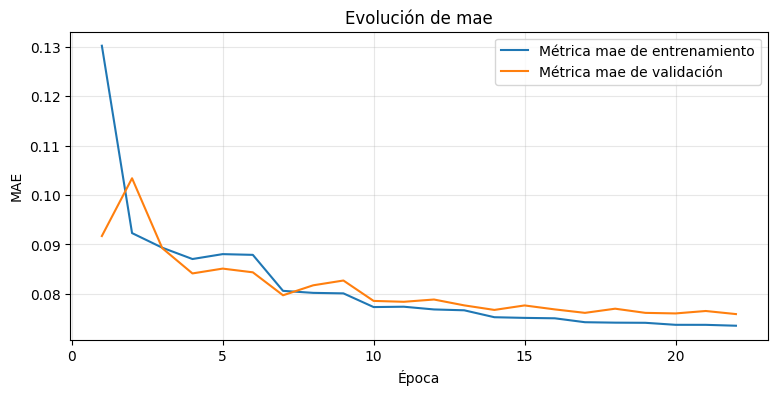

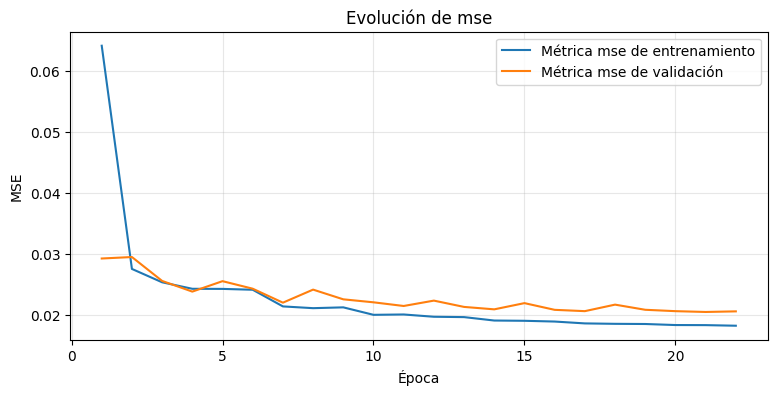

In [23]:
plot_training_metrics(model_data_norm_global)

In [24]:
from services.normalization import denormalize_standard, normalize_standard
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización global. La celda parte del `.keras`
# del modelo y del `.npz` de test, así que se ejecuta suelta tras la de rutas:
# no reentrena, no vuelve a cargar el `.npz` de datos completo y no necesita las
# variables que dejen en memoria las demás celdas del cuaderno.
y_pred_global = predict_test_set(
    GLOBAL_MODEL_PATH,
    GLOBAL_TEST_DATA_PATH,
    build_input=lambda test: normalize_standard(
        test["X_test"], test["X_mean"], test["X_std"]
    ),
    denormalize=lambda y_norm, test: denormalize_standard(
        y_norm, test["y_mean"], test["y_std"]
    )
)

# Las guardamos para la comparativa entre arquitecturas, en su propio cuaderno
save_predictions(GLOBAL_PREDICTIONS_PATH, y_pred=y_pred_global)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/predictions/dense-global_predictions.npz')

Graficamos un par de ejemplos

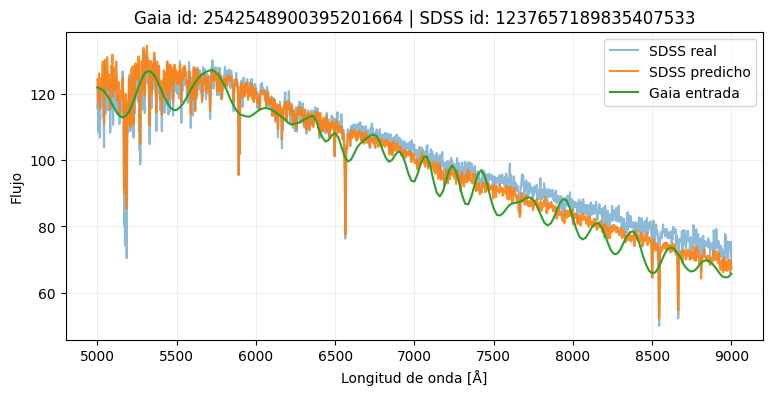

In [25]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

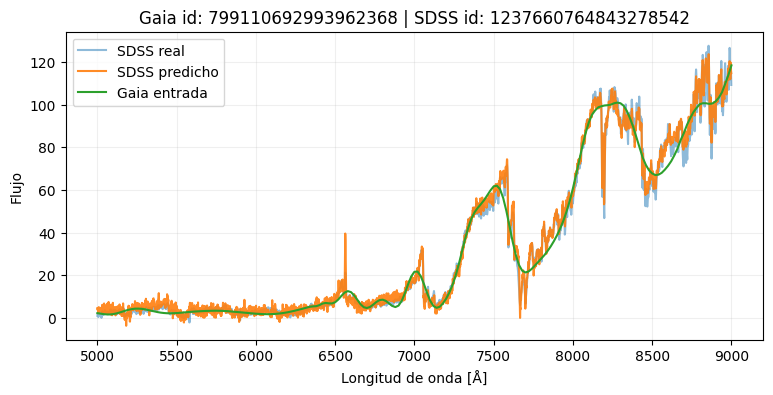

In [26]:
plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

In [27]:
from services.checkpoints import save_training_summary

test_results_global = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    GLOBAL_SUMMARY_PATH,
    model_data_norm_global,
    test_results_global,
    model_path=GLOBAL_MODEL_PATH,
    history_path=GLOBAL_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_global)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0100 - mae: 0.0778 - mse: 0.0217
{'loss': 0.009995597414672375, 'mae': 0.07781712710857391, 'mse': 0.021699268370866776}


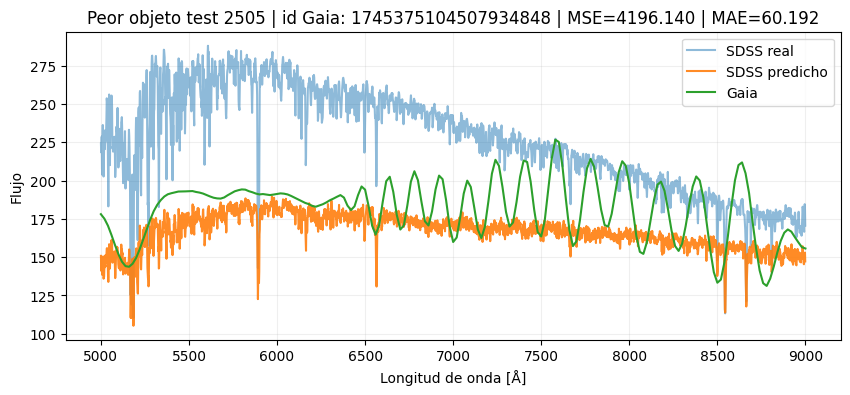

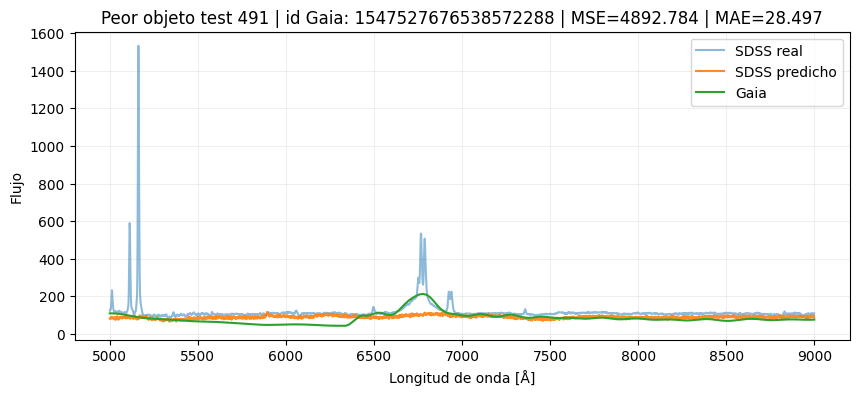

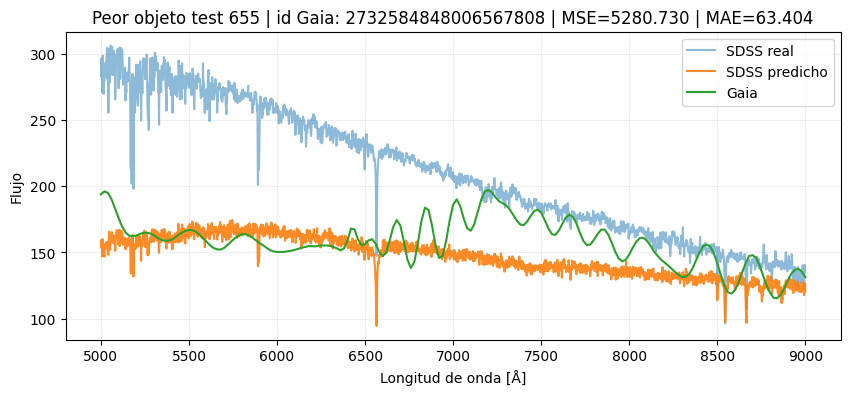

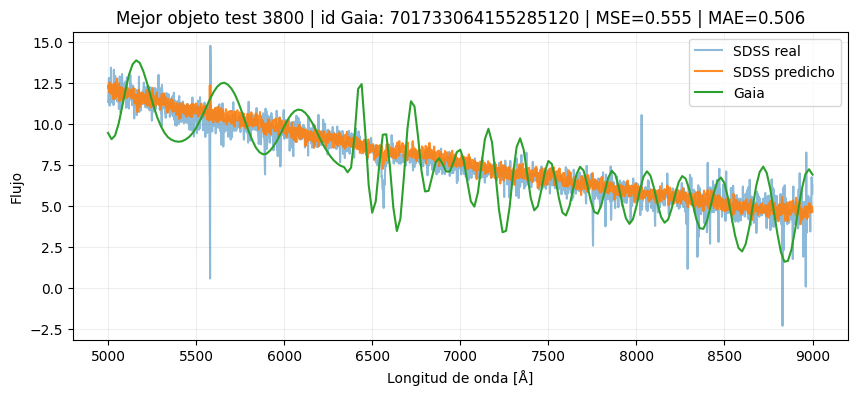

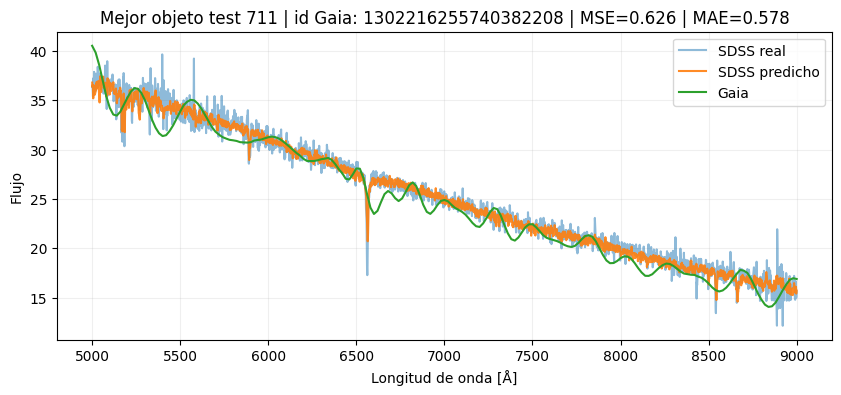

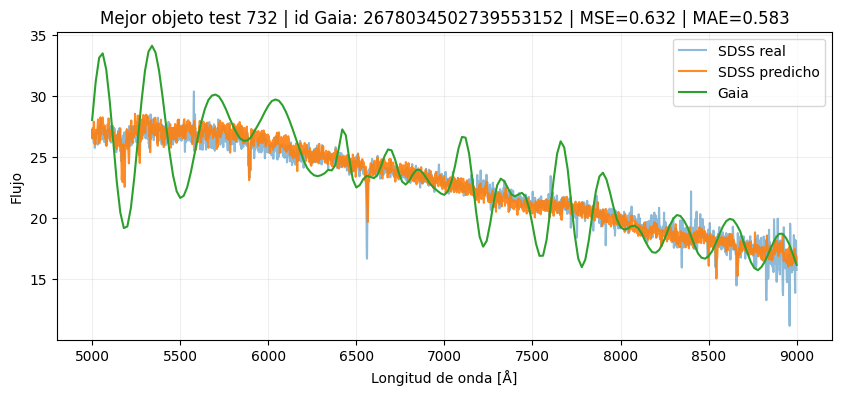

In [28]:
plot_worst_best_predictions(
    y_test,
    y_pred_global,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [29]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    load_gaia_table,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [30]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [31]:
# Cargamos Resources
resources = load_ispec_resources()

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.


In [32]:
# Cargamos la tabla de Gaia guardada en local
gaia_data_df = load_gaia_table()

Tabla de Gaia cargada: 121890 objetos.


In [33]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

# Guardamos la tabla nada más calcularla: el análisis son horas de iSpec, y así
# los histogramas de error se rehacen sin repetirlo
GLOBAL_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    GLOBAL_ISPEC_PATH,
    index=False
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando el espectro real de 2538096737295072384: Initial teff '3463.60498046875' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1541549494377790976: Initial Vmac '69.0' is out of range: '0.0' - '50.0'


Error analizando el espectro real de 1580491584892970880: Initial teff '3470.390380859375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 705041494643881984: Initial Vmac '99.79' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2545605714518955904: Initial teff '3458.80908203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 3123413192472575104: Initial Vmac '61.38' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2543233827419669248: Initial teff '3367.34033203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1314845963554562048: Initial teff '3131.83984375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro 

[2026-09-03 17:57:15,135] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.394347328505018 -4.594410140727862 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-03 17:57:16,285] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-03 17:57:16,321] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.299747718387562 -4.019970170990837 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-03 17:57:17,492] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-03 17:57:38,594] [WARNING] [atmospheres:_interpolate:110]: Target point '3536.254412898627 2.3055556420499217 -4.1290340978011795 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-03

Error analizando el espectro real de 1394500362602477184: Initial Vmac '151.26' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3267096031958970880: Initial teff '3341.4931640625' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2536119265632349440: Initial teff '3414.03125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 2536743616438313344: Initial teff '3487.251953125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 858606534186460800: Initial Vmac '139.37' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3847504615122111616: Initial Vmac '250.4' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3120288487803210496: Initial Vmac '88.64' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 3265951891326617984: Initial teff '3302.129150390625' is out of range: '3500.0' - '50000.0'
Espectros analizados: 250 | ajustes reutilizados: 2

In [34]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5187.687518,4.669123,-0.896216,-101.583870,-0.005873,0.009189
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5759.936370,4.676135,-1.122417,-2.272089,0.000825,0.003217
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.960733,4.165137,-0.689053,1.192509,-0.000603,-0.000366
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6027.122511,4.358290,-0.601315,-27.409515,-0.003278,0.290853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4222.902846,5.000000,-2.328583,-569.621154,0.000000,-0.936120
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5386.783546,4.704049,-0.995588,-31.555115,-0.015263,-0.006616
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5832.252558,4.585753,-0.951575,36.670971,-0.062003,0.019615
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5936.471760,4.716915,-2.041642,-7.912878,0.010524,-0.103703


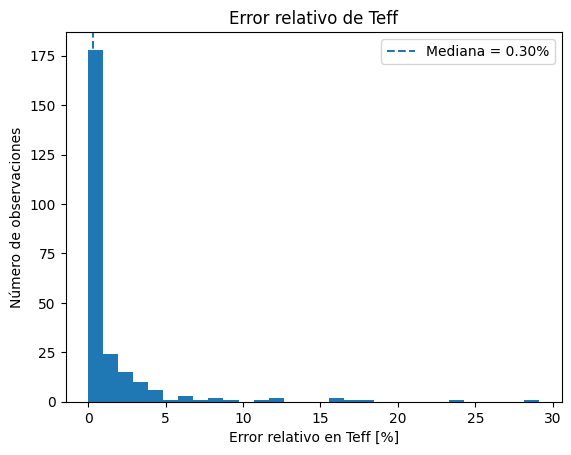

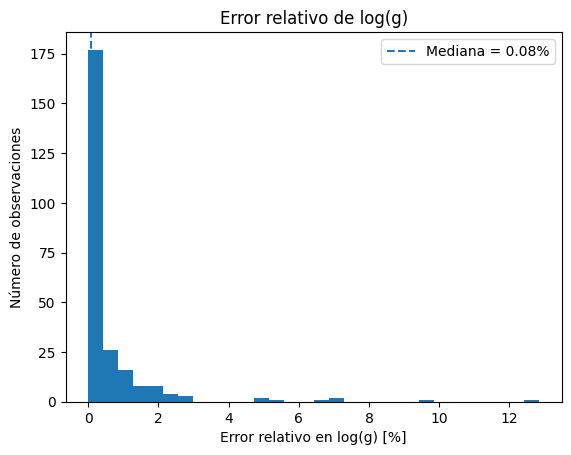

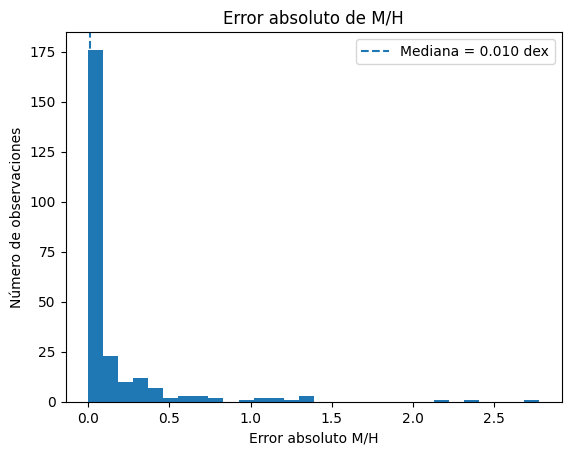

In [35]:
error_df = analyze_ispec_errors(results_df)

In [36]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5187.687518,4.669123,-0.896216,-101.583870,-0.005873,0.009189,101.583870,0.005873,0.009189,1.920565,0.125627
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5759.936370,4.676135,-1.122417,-2.272089,0.000825,0.003217,2.272089,0.000825,0.003217,0.039431,0.017639
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.960733,4.165137,-0.689053,1.192509,-0.000603,-0.000366,1.192509,0.000603,0.000366,0.019761,0.014472
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6027.122511,4.358290,-0.601315,-27.409515,-0.003278,0.290853,27.409515,0.003278,0.290853,0.452711,0.075168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4222.902846,5.000000,-2.328583,-569.621154,0.000000,-0.936120,569.621154,0.000000,0.936120,11.885619,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5386.783546,4.704049,-0.995588,-31.555115,-0.015263,-0.006616,31.555115,0.015263,0.006616,0.582376,0.323408
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5832.252558,4.585753,-0.951575,36.670971,-0.062003,0.019615,36.670971,0.062003,0.019615,0.632740,1.334033
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5936.471760,4.716915,-2.041642,-7.912878,0.010524,-0.103703,7.912878,0.010524,0.103703,0.133115,0.223606


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [37]:
from services.normalization import normalize_splits

# Cada espectro se normaliza con la mediana de su propio flujo absoluto, tanto
# la entrada de Gaia como el objetivo de SDSS
(X_train_norm_median_spec, X_val_norm_median_spec,
 X_test_norm_median_spec, X_scale_test) = normalize_splits(X_train, X_val, X_test)

(y_train_norm_median_spec, y_val_norm_median_spec,
 y_test_norm_median_spec, y_scale_test) = normalize_splits(y_train, y_val, y_test)

In [38]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    MEDIAN_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_scale_test=X_scale_test,
    y_scale_test=y_scale_test
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median_test_data.npz')

In [39]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_median_spec = ModelCheckpoint(
    MEDIAN_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_median_spec = CSVLogger(MEDIAN_HISTORY_PATH)

# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_median_spec,
        early_stop,
        reduce_lr,
        save_training_history_median_spec
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_median_spec.save(MEDIAN_MODEL_PATH)

model_data_median_spec = history.history
save_training_summary(
    MEDIAN_SUMMARY_PATH,
    model_data_median_spec,
    model_path=MEDIAN_MODEL_PATH,
    history_path=MEDIAN_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0194 - mae: 0.0925 - mse: 0.0455
Epoch 1: val_loss improved from None to 0.00469, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - loss: 0.0194 - mae: 0.0925 - mse: 0.0455 - val_loss: 0.0047 - val_mae: 0.0527 - val_mse: 0.0144 - learning_rate: 1.0000e-04
Epoch 2/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0046 - mae: 0.0520 - mse: 0.0120
Epoch 2: val_loss improved from 0.00469 to 0.00435, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - loss: 0.004

{'model': 'dense-median.keras',
 'history': 'dense-median_training_history.csv',
 'updated': '2026-09-03T18:39:34',
 'batch_size': 64,
 'epochs_completed': 16,
 'best_epoch': 16,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización por espectro con la mediana. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [41]:
from services.checkpoints import load_checkpoint, load_test_data
from services.normalization import normalize

model_median_spec, model_data_median_spec, summary_median = load_checkpoint(
    MEDIAN_MODEL_PATH, MEDIAN_HISTORY_PATH, MEDIAN_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(MEDIAN_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_scale_test = test_data["X_scale_test"]
y_scale_test = test_data["y_scale_test"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_median_spec = normalize(X_test, X_scale_test)
y_test_norm_median_spec = normalize(y_test, y_scale_test)

print("Checkpoint de", summary_median["updated"])
print(
    "Épocas completadas:", summary_median["epochs_completed"],
    "| mejor época:", summary_median["best_epoch"]
)
print("Métricas de test:", summary_median["test_metrics"])

Checkpoint de 2026-09-03T18:39:34
Épocas completadas: 16 | mejor época: 16
Métricas de test: None


In [42]:
from services.normalization import denormalize, normalize
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización por espectro con la mediana
y_pred_median_spec = predict_test_set(
    MEDIAN_MODEL_PATH,
    MEDIAN_TEST_DATA_PATH,
    build_input=lambda test: normalize(test["X_test"], test["X_scale_test"]),
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"])
)

save_predictions(MEDIAN_PREDICTIONS_PATH, y_pred=y_pred_median_spec)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/predictions/dense-median_predictions.npz')

In [43]:
from services.checkpoints import save_training_summary

test_results_median = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    MEDIAN_SUMMARY_PATH,
    model_data_median_spec,
    test_results_median,
    model_path=MEDIAN_MODEL_PATH,
    history_path=MEDIAN_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_median)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - mae: 0.0436 - mse: 0.0084
{'loss': 0.0032900648657232523, 'mae': 0.04355844482779503, 'mse': 0.008360960520803928}


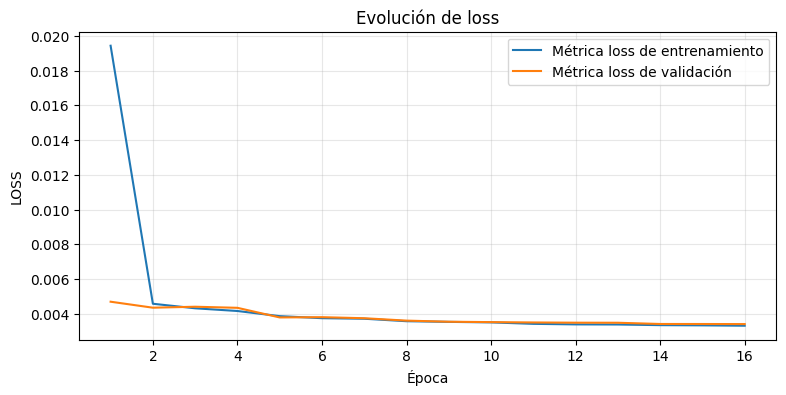

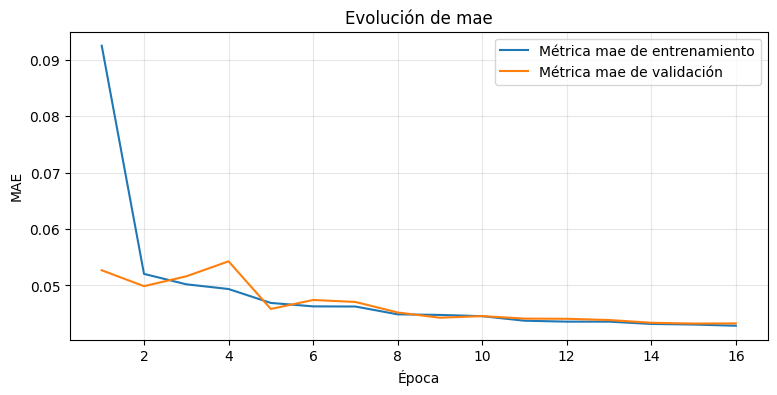

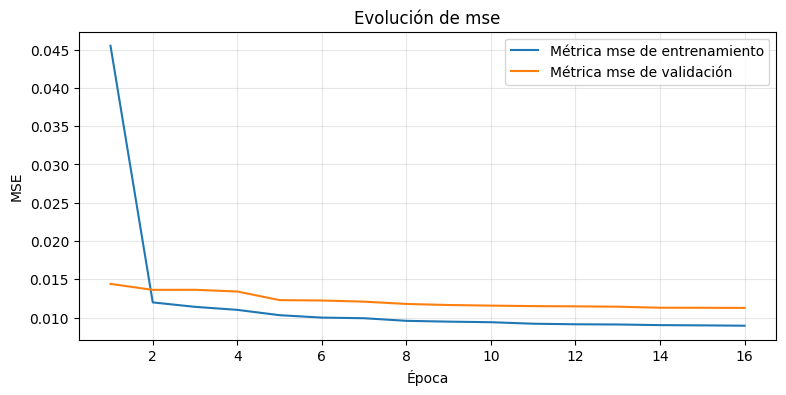

In [44]:
from model_functions import plot_training_metrics

plot_training_metrics(model_data_median_spec)

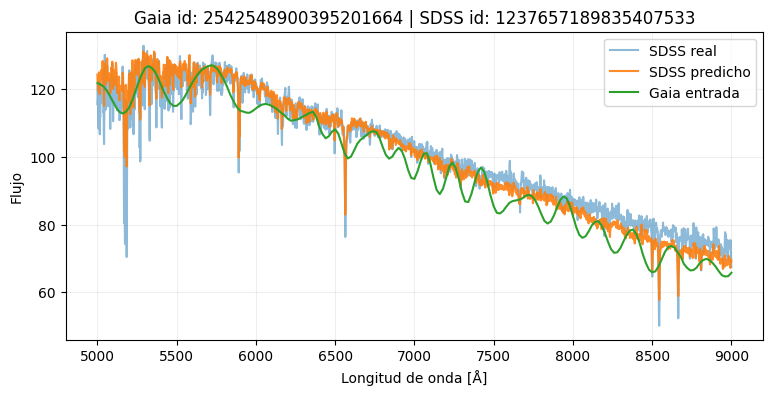

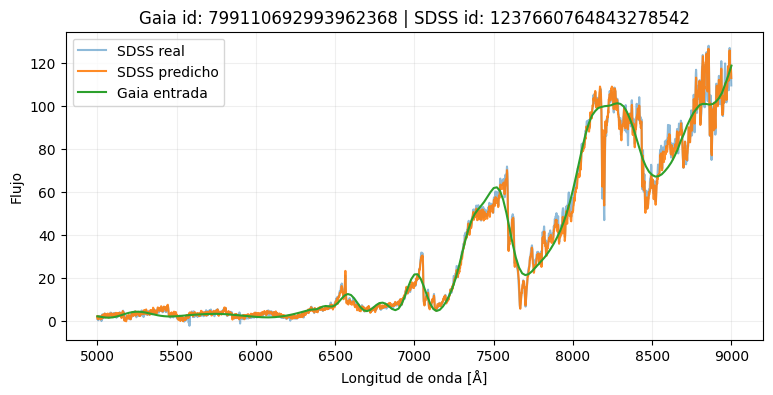

In [45]:
from model_functions import plot_prediction_example

plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

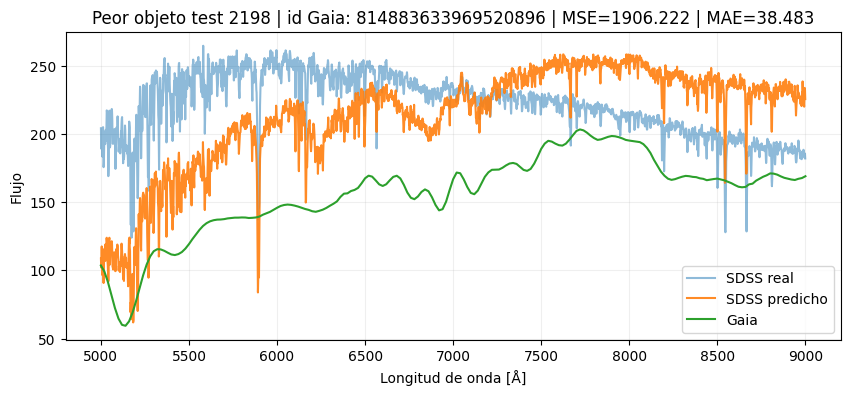

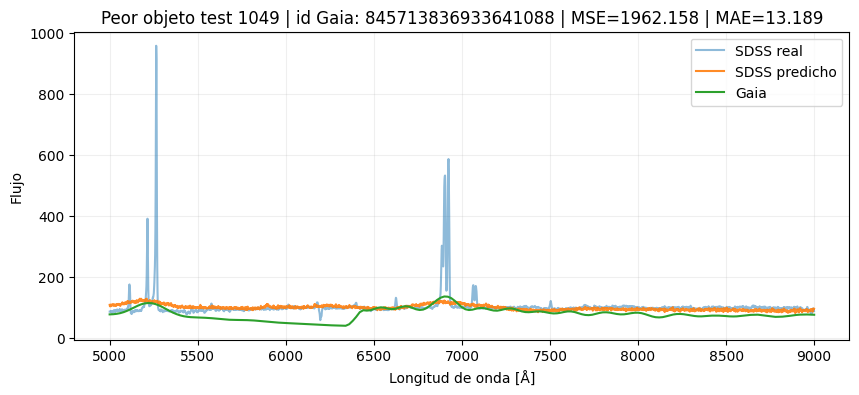

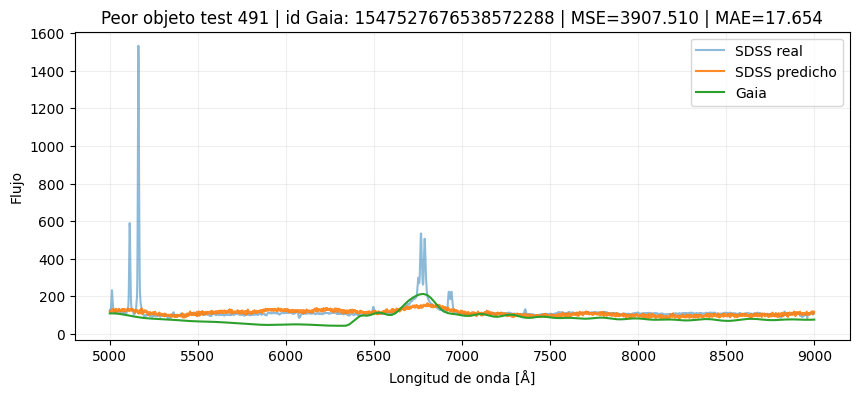

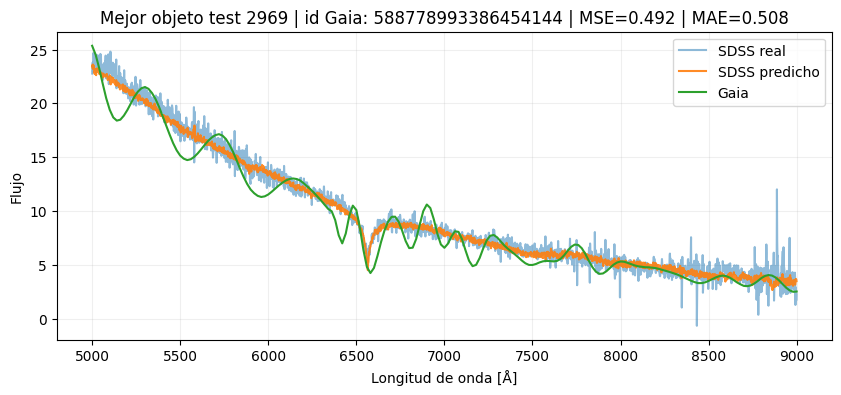

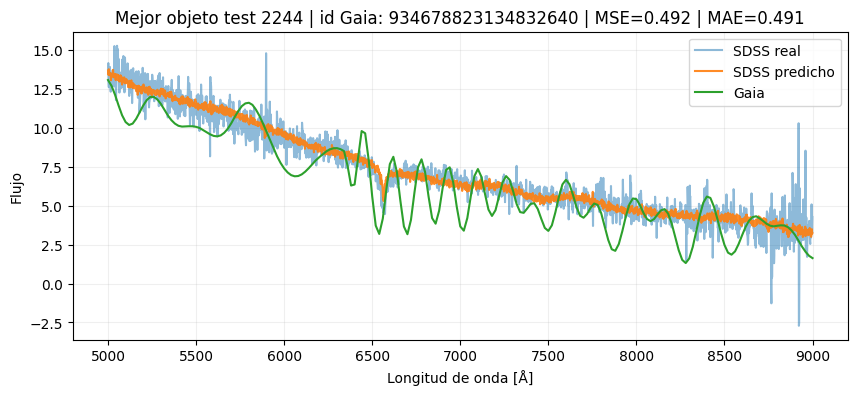

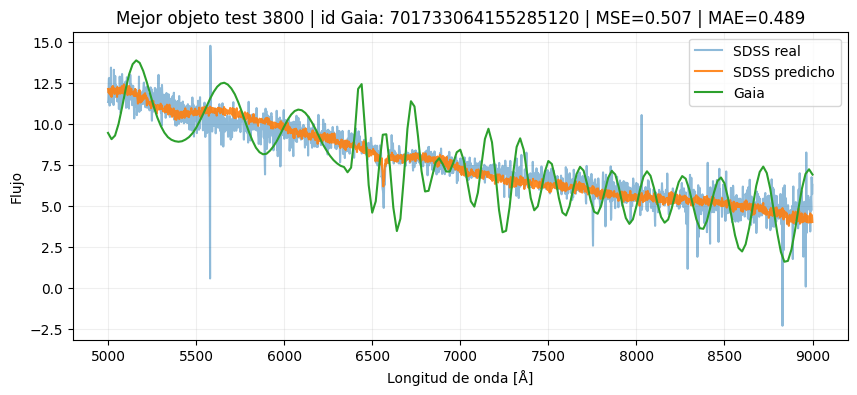

In [46]:
from model_functions import plot_worst_best_predictions

plot_worst_best_predictions(
    y_test,
    y_pred_median_spec,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Igual que en el anterior caso, analizamos con iSpec

In [10]:
from iSpec_functions import (
    analyze_sample_real_vs_pred,
    load_ispec_resources,
    load_gaia_table
)

# Los dos cargadores guardan en caché de módulo lo que leen, así que repetir
# aquí la llamada no vuelve a leer del disco los recursos de iSpec ni la tabla
# de Gaia: solo recupera lo que ya cargó la primera sección que los pidiera
resources = load_ispec_resources()
gaia_data_df = load_gaia_table()

results_2_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_median_spec,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

# Guardamos la tabla nada más calcularla: el análisis son horas de iSpec, y así
# los histogramas de error se rehacen sin repetirlo
MEDIAN_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_2_df.to_csv(
    MEDIAN_ISPEC_PATH,
    index=False
)

display(results_2_df)

NameError: name 'analyze_sample_real_vs_pred' is not defined

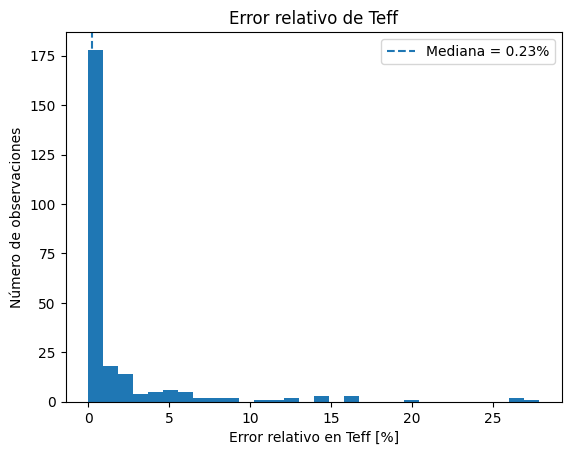

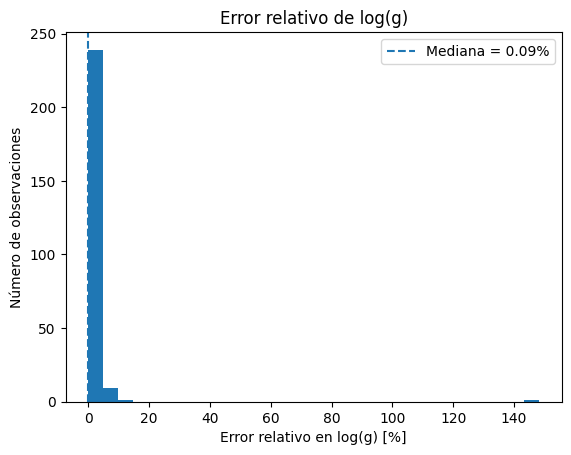

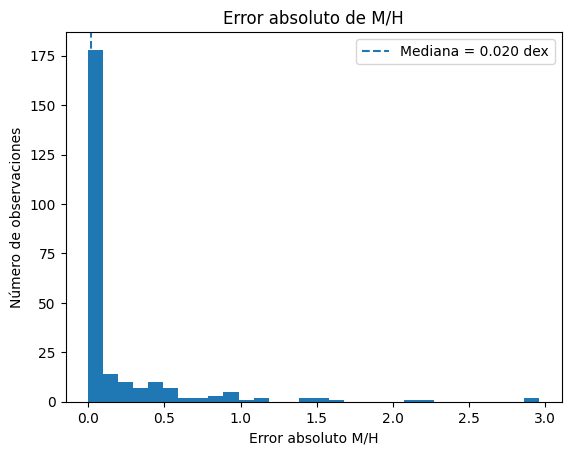

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5279.831876,4.673511,-0.902599,-9.439512,-0.001485,0.002805,9.439512,0.001485,0.002805,0.178465,0.031760
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5759.960621,4.676143,-1.121750,-2.247838,0.000833,0.003885,2.247838,0.000833,0.003885,0.039010,0.017822
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.087677,4.166085,-0.689011,0.319453,0.000345,-0.000324,0.319453,0.000345,0.000324,0.005294,0.008293
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6028.730211,4.353779,-0.646943,-25.801815,-0.007789,0.245226,25.801815,0.007789,0.245226,0.426157,0.178589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4769.406723,5.000000,-1.378068,-23.117276,0.000000,0.014395,23.117276,0.000000,0.014395,0.482361,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5386.827533,4.704106,-0.995573,-31.511127,-0.015205,-0.006601,31.511127,0.015205,0.006601,0.581564,0.322196
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5812.844624,4.609637,-0.949845,17.263037,-0.038118,0.021345,17.263037,0.038118,0.021345,0.297865,0.820137
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5937.046709,4.717469,-2.068850,-7.337928,0.011077,-0.130911,7.337928,0.011077,0.130911,0.123443,0.235359


In [48]:
from iSpec_functions import analyze_ispec_errors

error_2_df = analyze_ispec_errors(results_2_df)
display(error_2_df)

Misma estructura pero con normalización con el máximo por espectro.

In [49]:
from services.normalization import normalize_splits

# Cada espectro se normaliza con el máximo de su propio flujo absoluto, tanto
# la entrada de Gaia como el objetivo de SDSS
(X_train_norm_max, X_val_norm_max, X_test_norm_max,
 X_max_test) = normalize_splits(X_train, X_val, X_test, statistic="max")

(y_train_norm_max, y_val_norm_max, y_test_norm_max,
 y_max_test) = normalize_splits(y_train, y_val, y_test, statistic="max")

In [50]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    MAX_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_max_test=X_max_test,
    y_max_test=y_max_test
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max_test_data.npz')

In [51]:
from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_max_spectrum = ModelCheckpoint(
    MAX_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_max_spectrum = CSVLogger(MAX_HISTORY_PATH)

model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_max_spectrum,
        early_stop,
        reduce_lr,
        save_training_history_max_spectrum
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_per_spectrum_max.save(MAX_MODEL_PATH)

model_data_max = history_max_spectrum.history
save_training_summary(
    MAX_SUMMARY_PATH,
    model_data_max,
    model_path=MAX_MODEL_PATH,
    history_path=MAX_HISTORY_PATH,
    batch_size=batch_size
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0103 - mae: 0.0921 - mse: 0.0206
Epoch 1: val_loss improved from None to 0.00545, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - loss: 0.0103 - mae: 0.0921 - mse: 0.0206 - val_loss: 0.0055 - val_mae: 0.0741 - val_mse: 0.0109 - learning_rate: 1.0000e-04
Epoch 2/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0051 - mae: 0.0693 - mse: 0.0102
Epoch 2: val_loss improved from 0.00545 to 0.00524, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - loss: 0.0051 - mae: 0.0

{'model': 'dense-max.keras',
 'history': 'dense-max_training_history.csv',
 'updated': '2026-09-03T20:57:54',
 'batch_size': 64,
 'epochs_completed': 13,
 'best_epoch': 13,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización por espectro con el máximo. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [12]:
from services.checkpoints import load_checkpoint, load_test_data
from services.normalization import normalize

model_per_spectrum_max, model_data_max, summary_max = load_checkpoint(
    MAX_MODEL_PATH, MAX_HISTORY_PATH, MAX_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(MAX_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_max_test = test_data["X_max_test"]
y_max_test = test_data["y_max_test"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_max = normalize(X_test, X_max_test)
y_test_norm_max = normalize(y_test, y_max_test)

print("Checkpoint de", summary_max["updated"])
print(
    "Épocas completadas:", summary_max["epochs_completed"],
    "| mejor época:", summary_max["best_epoch"]
)
print("Métricas de test:", summary_max["test_metrics"])

2026-09-03 21:34:57.806881: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 21:34:57.909042: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 21:35:00.487392: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 21:35:01.573717: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Checkpoint de 2026-09-03T20:58:02
Épocas completadas: 13 | mejor época: 13
Métricas de test: {'loss': 0.004669091198593378, 'mae': 0.06548231095075607, 'mse': 0.009338715113699436}


In [13]:
from services.normalization import denormalize, normalize
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización por espectro con el máximo
y_pred_per_spectrum_max = predict_test_set(
    MAX_MODEL_PATH,
    MAX_TEST_DATA_PATH,
    build_input=lambda test: normalize(test["X_test"], test["X_max_test"]),
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_max_test"])
)

save_predictions(MAX_PREDICTIONS_PATH, y_pred=y_pred_per_spectrum_max)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/predictions/dense-max_predictions.npz')

In [14]:
from services.checkpoints import save_training_summary

test_results_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    MAX_SUMMARY_PATH,
    model_data_max,
    test_results_max,
    model_path=MAX_MODEL_PATH,
    history_path=MAX_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_max)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0047 - mae: 0.0655 - mse: 0.0093
{'loss': 0.004669091198593378, 'mae': 0.06548231095075607, 'mse': 0.009338715113699436}


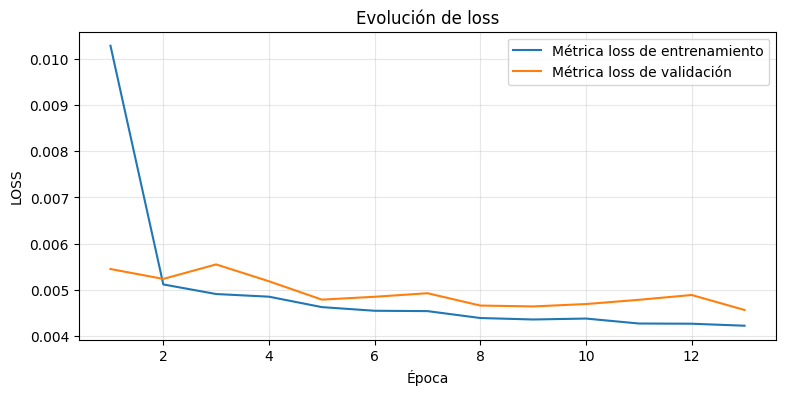

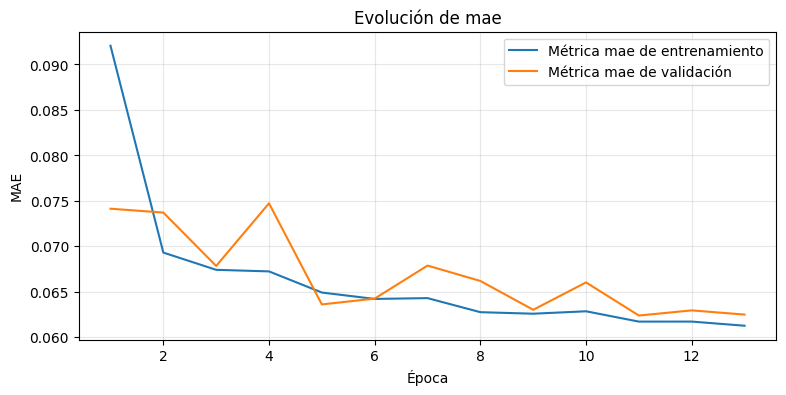

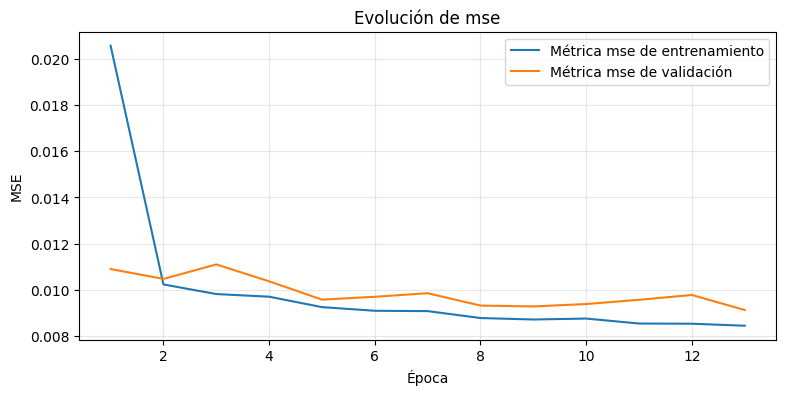

In [15]:
from model_functions import plot_training_metrics

plot_training_metrics(model_data_max)


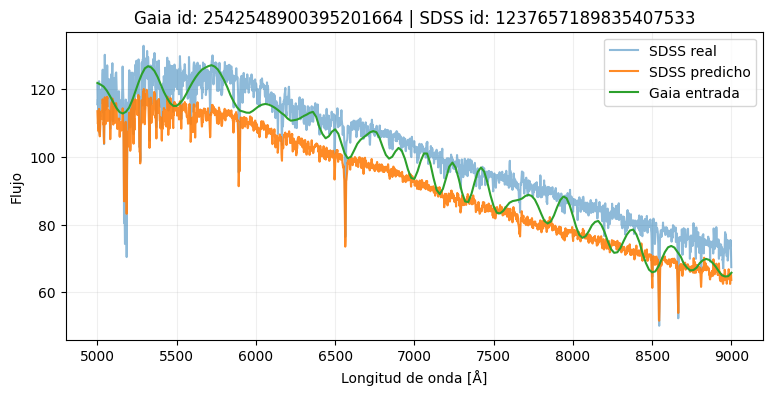

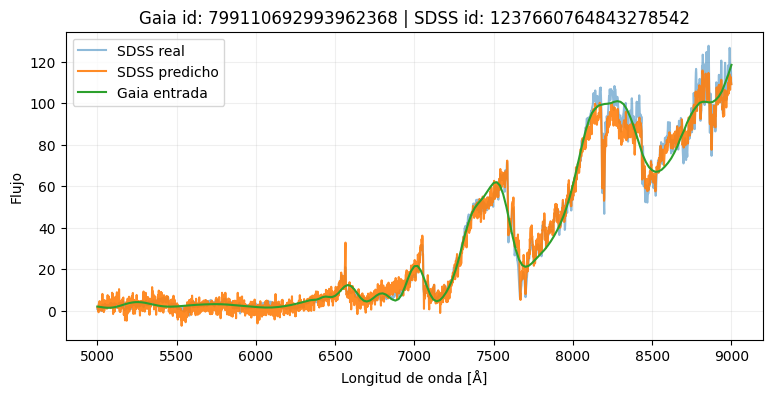

In [16]:
from model_functions import plot_prediction_example

plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

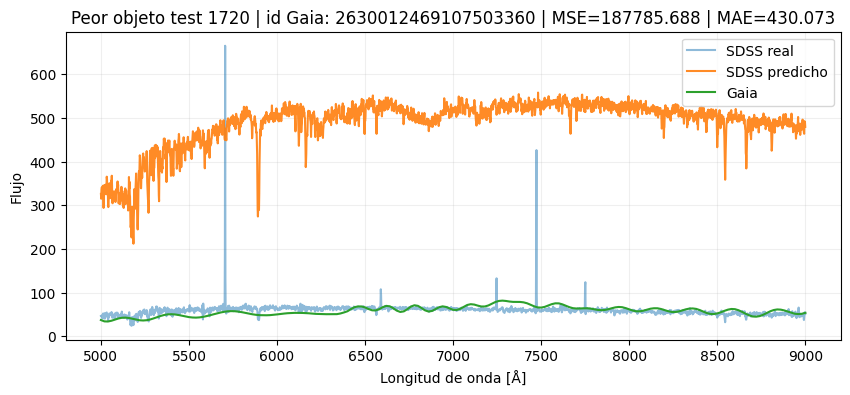

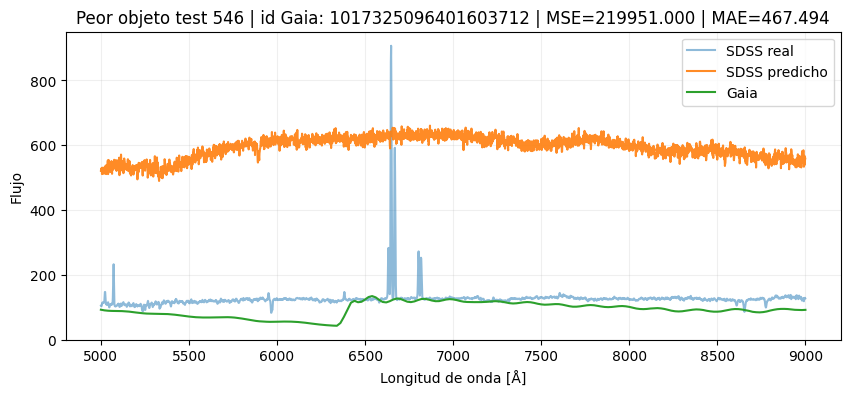

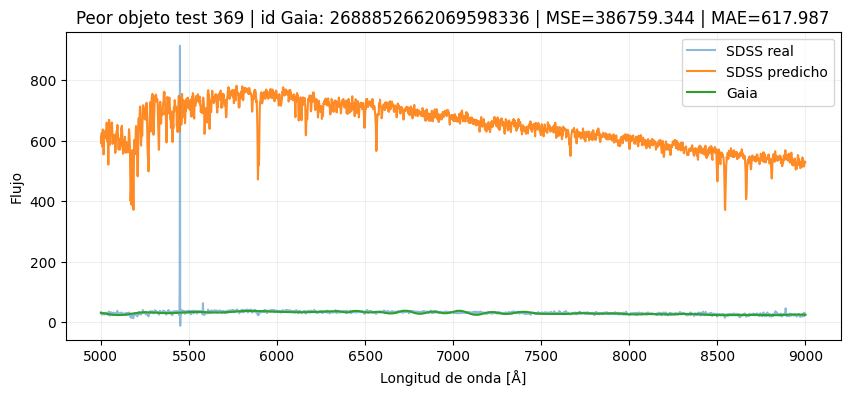

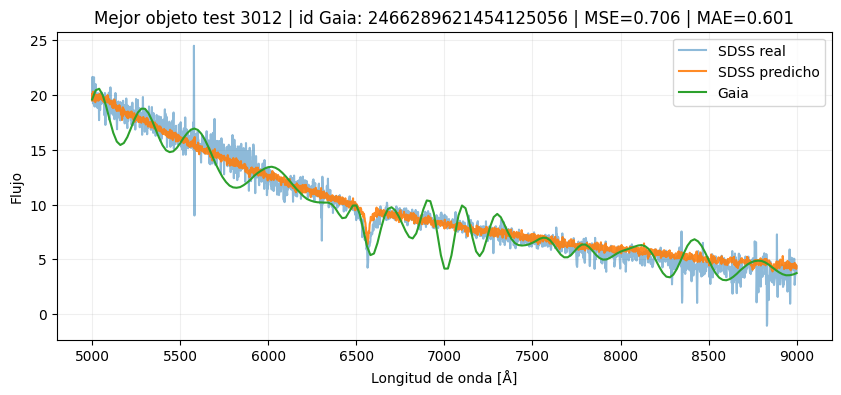

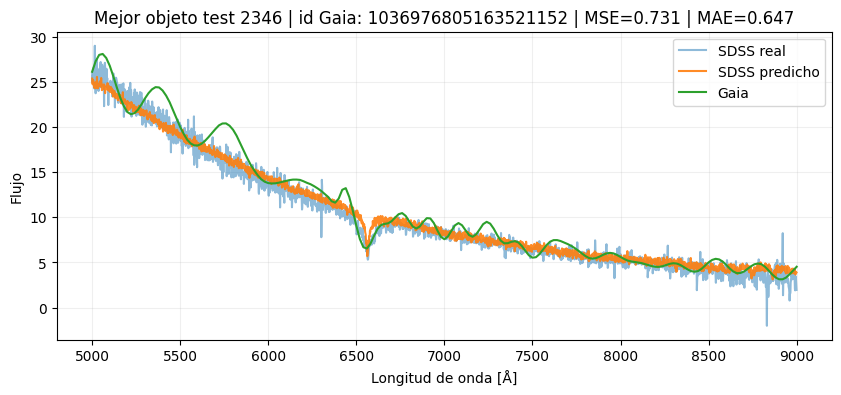

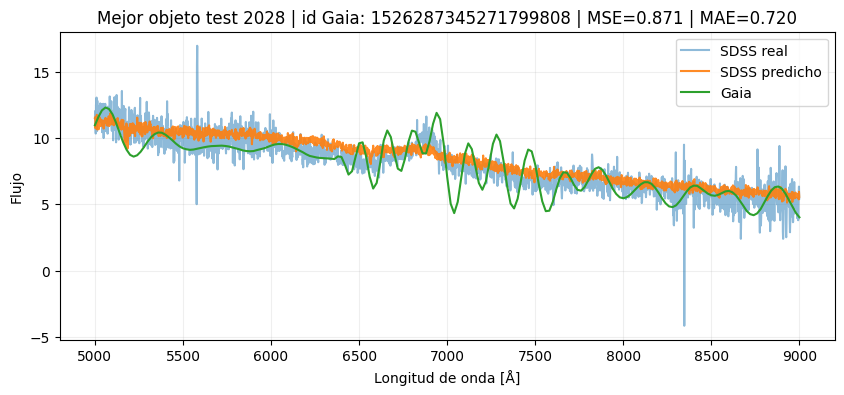

In [17]:
from model_functions import plot_worst_best_predictions

plot_worst_best_predictions(
    y_test,
    y_pred_per_spectrum_max,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [19]:
from iSpec_functions import (
    analyze_sample_real_vs_pred,
    load_ispec_resources,
    load_gaia_table
)

# Los dos cargadores guardan en caché de módulo lo que leen, así que repetir
# aquí la llamada no vuelve a leer del disco los recursos de iSpec ni la tabla
# de Gaia: solo recupera lo que ya cargó la primera sección que los pidiera
resources = load_ispec_resources()
gaia_data_df = load_gaia_table()

results_3_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_per_spectrum_max,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

# Guardamos la tabla nada más calcularla: el análisis son horas de iSpec, y así
# los histogramas de error se rehacen sin repetirlo
MAX_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_3_df.to_csv(
    MAX_ISPEC_PATH,
    index=False
)

display(results_3_df)

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.
Tabla de Gaia cargada: 121890 objetos.


Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando el espectro real de 2538096737295072384: Initial teff '3463.60498046875' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1541549494377790976: Initial Vmac '69.0' is out of range: '0.0' - '50.0'


Error analizando el espectro real de 1580491584892970880: Initial teff '3470.390380859375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 705041494643881984: Initial Vmac '99.79' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2545605714518955904: Initial teff '3458.80908203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 3123413192472575104: Initial Vmac '61.38' is out of range: '0.0' - '50.0'
Error analizando el espectro real de 2543233827419669248: Initial teff '3367.34033203125' is out of range: '3500.0' - '50000.0'
Error analizando el espectro real de 1314845963554562048: Initial teff '3131.83984375' is out of range: '3500.0' - '50000.0'
Error analizando el espectro 

[2026-09-03 23:42:40,538] [WARNING] [atmospheres:_interpolate:110]: Target point '6874.581616648486 4.3915791439195235 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-09-03 23:42:41,640] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando el espectro real de 3265951891326617984: Initial teff '3302.129150390625' is out of range: '3500.0' - '50000.0'
Espectros analizados: 250 | ajustes reutilizados: 250 reales, 20 predichos


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5286.146435,4.672385,-0.907633,-3.124953,-0.002611,-0.002229
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5760.057247,4.678430,-1.122333,-2.151212,0.003120,0.003301
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6033.668945,4.165500,-0.689000,-1.099279,-0.000240,-0.000313
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6026.830128,4.360271,-0.636355,-27.701897,-0.001297,0.255814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4833.295788,5.000000,-1.151346,40.771789,0.000000,0.241117
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5500.910448,4.692684,-0.998317,82.571788,-0.026628,-0.009345
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5836.234441,4.586314,-0.949866,40.652854,-0.061441,0.021324
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5964.786152,4.735889,-2.063416,20.401515,0.029498,-0.125476


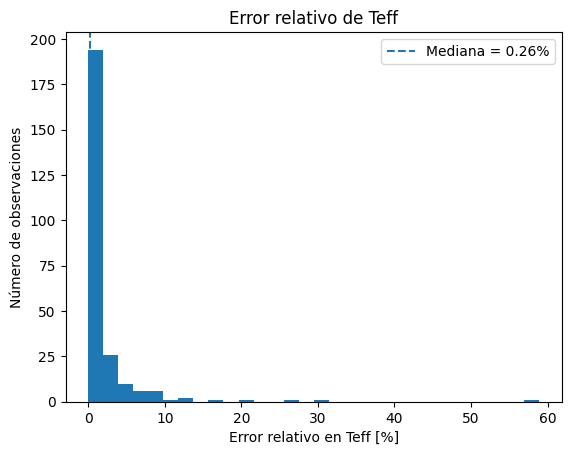

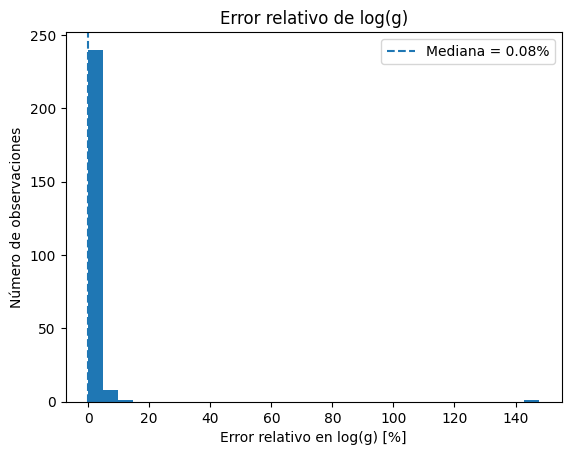

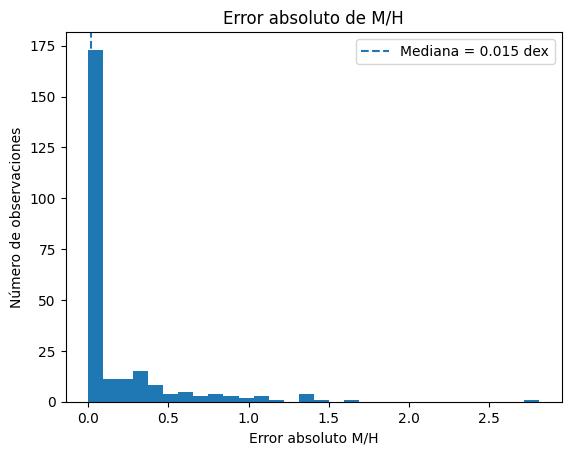

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5286.146435,4.672385,-0.907633,-3.124953,-0.002611,-0.002229,3.124953,0.002611,0.002229,0.059081,0.055849
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5760.057247,4.678430,-1.122333,-2.151212,0.003120,0.003301,2.151212,0.003120,0.003301,0.037333,0.066731
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6033.668945,4.165500,-0.689000,-1.099279,-0.000240,-0.000313,1.099279,0.000240,0.000313,0.018216,0.005751
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6026.830128,4.360271,-0.636355,-27.701897,-0.001297,0.255814,27.701897,0.001297,0.255814,0.457540,0.029746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4833.295788,5.000000,-1.151346,40.771789,0.000000,0.241117,40.771789,0.000000,0.241117,0.850737,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5500.910448,4.692684,-0.998317,82.571788,-0.026628,-0.009345,82.571788,0.026628,0.009345,1.523932,0.564236
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5836.234441,4.586314,-0.949866,40.652854,-0.061441,0.021324,40.652854,0.061441,0.021324,0.701446,1.321949
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5964.786152,4.735889,-2.063416,20.401515,0.029498,-0.125476,20.401515,0.029498,0.125476,0.343207,0.626760


In [20]:
from iSpec_functions import analyze_ispec_errors

error_3_df = analyze_ispec_errors(results_3_df)
display(error_3_df)

In [21]:
# Ploteamos histograma para comparar modelos y errores
# Primero TEFF
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["rel_error_teff"].dropna(),
    bins=40,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["rel_error_teff"].dropna(),
    bins=40,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["rel_error_teff"].dropna(),
    bins=40,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_teff_global = error_df["rel_error_teff"].median()
median_teff_median = error_2_df["rel_error_teff"].median()
median_teff_max = error_3_df["rel_error_teff"].median()

plt.axvline(
    median_teff_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_teff_global:.2f}%"
)

plt.axvline(
    median_teff_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_teff_median:.2f}%"
)

plt.axvline(
    median_teff_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_teff_max:.2f}%"
)

plt.xlabel("Error relativo de Teff [%]")
plt.ylabel("Observaciones")
plt.title("Comparación del error relativo de Teff")
plt.legend()

plt.show()

# logg
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["rel_error_logg"].dropna(),
    bins=40,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["rel_error_logg"].dropna(),
    bins=40,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["rel_error_logg"].dropna(),
    bins=40,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_logg_global = error_df["rel_error_logg"].median()
median_logg_median = error_2_df["rel_error_logg"].median()
median_logg_max = error_3_df["rel_error_logg"].median()

plt.axvline(
    median_logg_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_logg_global:.2f}%"
)

plt.axvline(
    median_logg_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_logg_median:.2f}%"
)

plt.axvline(
    median_logg_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_logg_max:.2f}%"
)

plt.xlabel("Error relativo de log(g) [%]")
plt.ylabel("Observaciones")
plt.title("Comparación del error relativo de log(g)")
plt.legend()

plt.show()

# m/h
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["abs_error_mh"].dropna(),
    bins=40,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["abs_error_mh"].dropna(),
    bins=40,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["abs_error_mh"].dropna(),
    bins=40,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_MH_global = error_df["abs_error_mh"].median()
median_MH_median = error_2_df["abs_error_mh"].median()
median_MH_max = error_3_df["abs_error_mh"].median()

plt.axvline(
    median_MH_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_MH_global:.4f}"
)

plt.axvline(
    median_MH_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_MH_median:.4f}"
)

plt.axvline(
    median_MH_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_MH_max:.4f}"
)

plt.xlabel("Error absoluto de M/H [dex]")
plt.ylabel("Observaciones")
plt.title("Comparación del error absoluto de M/H")
plt.legend()

plt.show()

NameError: name 'plt' is not defined